Given a 2D array of characters grid of size m x n, you need to find if there exists any cycle consisting of the same value in grid.

A cycle is a path of length 4 or more in the grid that starts and ends at the same cell. From a given cell, you can move to one of the cells adjacent to it - in one of the four directions (up, down, left, or right), if it has the same value of the current cell.

Also, you cannot move to the cell that you visited in your last move. For example, the cycle (1, 1) -> (1, 2) -> (1, 1) is invalid because from (1, 2) we visited (1, 1) which was the last visited cell.

Return true if any cycle of the same value exists in grid, otherwise, return false.

 

Example 1:

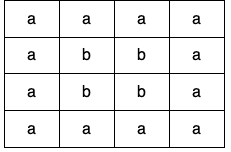

Input: grid = [["a","a","a","a"],["a","b","b","a"],["a","b","b","a"],["a","a","a","a"]]
Output: true
Explanation: There are two valid cycles shown in different colors in the image below:

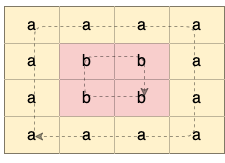

Example 2:

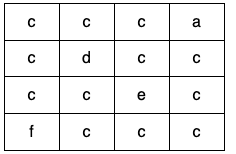

Input: grid = [["c","c","c","a"],["c","d","c","c"],["c","c","e","c"],["f","c","c","c"]]
Output: true
Explanation: There is only one valid cycle highlighted in the image below:

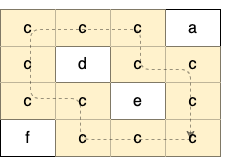

Example 3:

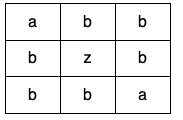

Input: grid = [["a","b","b"],["b","z","b"],["b","b","a"]]
Output: false

 

Constraints:

    m == grid.length
    n == grid[i].length
    1 <= m, n <= 500
    grid consists only of lowercase English letters.


In [ ]:
class UnionFind:
    def __init__(self, n: int):
        self.n = n
        self.setCount = n
        self.parent = list(range(n))
        self.size = [1] * n

    def findset(self, x: int) -> int:
        if self.parent[x] == x:
            return x
        self.parent[x] = self.findset(self.parent[x])
        return self.parent[x]

    def unite(self, x: int, y: int):
        if self.size[x] < self.size[y]:
            x, y = y, x
        self.parent[y] = x
        self.size[x] += self.size[y]
        self.setCount -= 1

    def findAndUnite(self, x: int, y: int) -> bool:
        parentX, parentY = self.findset(x), self.findset(y)
        if parentX != parentY:
            self.unite(parentX, parentY)
            return True
        return False


class Solution:
    def containsCycle(self, grid: List[List[str]]) -> bool:
        m, n = len(grid), len(grid[0])
        uf = UnionFind(m * n)
        for i in range(m):
            for j in range(n):
                if i > 0 and grid[i][j] == grid[i - 1][j]:
                    if not uf.findAndUnite(i * n + j, (i - 1) * n + j):
                        return True
                if j > 0 and grid[i][j] == grid[i][j - 1]:
                    if not uf.findAndUnite(i * n + j, i * n + j - 1):
                        return True
        return False
        